# Lab 5: Wizualizacja aktywacji warstw ukrytych

MNIST i Fashion-MNIST, redukcja wymiaru (t-SNE, TriMAP, PaCMAP, UMAP) oraz klasyfikacja KNN na embeddingach UMAP.


In [11]:
import sys

!{sys.executable} -m pip install -q -r requirements.txt

import numpy, tensorflow
print('Python', sys.version.split()[0])
print('numpy', numpy.__version__, '| tensorflow', tensorflow.__version__)


Python 3.10.11
numpy 2.0.2 | tensorflow 2.18.1



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pacmap
import trimap
import umap
from keras import Model
from keras.datasets import fashion_mnist, mnist
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

RANDOM_SEED = 42
NB_CLASSES = 10
DROPOUT = 0.5
EPOCHS = 20
BATCH_SIZE = 128
N_NEIGHBORS_LIST = [3, 5, 10]
VIZ_SAMPLE_SIZE = 10_000
UMAP_NEIGHBORS = 15


In [13]:
def plot_history(network_history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(network_history.history['loss'], label='Training')
    axes[0].plot(network_history.history['val_loss'], label='Validation')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(network_history.history['accuracy'], label='Training')
    axes[1].plot(network_history.history['val_accuracy'], label='Validation')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def build_model():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dropout(DROPOUT),
        Dense(64, activation='relu'),
        Dropout(DROPOUT),
        Dense(NB_CLASSES, activation='softmax'),
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


def get_activation_model(model):
    return Model(
        inputs=model.inputs,
        outputs=[model.layers[0].output, model.layers[2].output, model.layers[4].output],
    )


def load_and_preprocess(load_fn):
    (X_train, y_train), (X_test, y_test) = load_fn()
    X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
    X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
    Y_train = to_categorical(y_train, NB_CLASSES)
    Y_test = to_categorical(y_test, NB_CLASSES)
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_train, Y_train, train_size=5 / 6, random_state=RANDOM_SEED
    )
    return X_train, X_val, X_test, Y_train, Y_val, Y_test, y_train, y_test


def stratified_subsample(X, y, n_samples, random_state=RANDOM_SEED):
    rng = np.random.RandomState(random_state)
    classes = np.unique(y)
    per_class = max(1, n_samples // len(classes))
    indices = []
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        n = min(per_class, len(cls_idx))
        indices.extend(rng.choice(cls_idx, n, replace=False))
    indices = np.array(indices)
    return X[indices], y[indices], indices


def fit_tsne(X):
    return TSNE(n_components=2, random_state=RANDOM_SEED, init='pca', learning_rate='auto').fit_transform(X)


def fit_trimap(X):
    n = X.shape[0]
    tri = trimap.TRIMAP(
        n_dims=2,
        n_inliers=min(12, n - 1),
        n_outliers=min(4, max(1, n // 5)),
        n_random=min(3, max(1, n // 7)),
        n_iters=450,
        apply_pca=True,
        verbose=False,
    )
    return tri.fit_transform(X)


def fit_pacmap(X):
    n = X.shape[0]
    pac_neighbors = max(5, min(10, n - 1))
    pac = pacmap.PaCMAP(
        n_components=2,
        n_neighbors=pac_neighbors,
        MN_ratio=0.5,
        FP_ratio=2.0,
        random_state=RANDOM_SEED,
    )
    embedding = pac.fit_transform(X, init='pca')
    return embedding, pac


def fit_umap_train_test(X_train, X_test):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=0.1,
        random_state=RANDOM_SEED,
    )
    train_emb = reducer.fit_transform(X_train)
    test_emb = reducer.transform(X_test)
    return train_emb, test_emb, reducer


def plot_embedding_grid(train_embeddings, test_embeddings, y_train, y_test, title_prefix):
    methods = list(train_embeddings.keys())
    fig, axes = plt.subplots(2, len(methods), figsize=(4 * len(methods), 8))
    if len(methods) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for col, method in enumerate(methods):
        axes[0, col].scatter(
            train_embeddings[method][:, 0],
            train_embeddings[method][:, 1],
            c=y_train,
            cmap='tab10',
            s=2,
            alpha=0.7,
        )
        axes[0, col].set_title(f'{method}: train')
        axes[0, col].set_xticks([])
        axes[0, col].set_yticks([])

        if test_embeddings.get(method) is not None:
            axes[1, col].scatter(
                test_embeddings[method][:, 0],
                test_embeddings[method][:, 1],
                c=y_test,
                cmap='tab10',
                s=2,
                alpha=0.7,
            )
            axes[1, col].set_title(f'{method}: test')
        else:
            axes[1, col].text(0.5, 0.5, 'brak transformacji', ha='center', va='center')
            axes[1, col].set_title(f'{method}: test')
        axes[1, col].set_xticks([])
        axes[1, col].set_yticks([])

    fig.suptitle(title_prefix, y=1.02)
    plt.tight_layout()
    plt.show()


def run_dimred_and_plots(X_train, X_test, y_train, y_test, title_prefix):
    print(title_prefix)
    X_viz, y_viz, viz_idx = stratified_subsample(X_train, y_train, VIZ_SAMPLE_SIZE)

    pac_train, _ = fit_pacmap(X_viz)
    train_embeddings = {
        't-SNE': fit_tsne(X_viz),
        'TriMAP': fit_trimap(X_viz),
        'PaCMAP': pac_train,
    }
    umap_train, umap_test, _ = fit_umap_train_test(X_train, X_test)
    train_embeddings['UMAP'] = umap_train[viz_idx]

    test_embeddings = {
        't-SNE': None,
        'TriMAP': None,
        'PaCMAP': None,
        'UMAP': umap_test,
    }

    y_plot_test = y_test

    plot_embedding_grid(
        train_embeddings,
        test_embeddings,
        y_viz,
        y_plot_test,
        title_prefix,
    )
    return umap_train, umap_test


def evaluate_knn(X_train_embedded, X_test_embedded, y_train, y_test, n_neighbors_list):
    results = []
    for n_neighbors in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train_embedded, y_train)
        y_pred = knn.predict(X_test_embedded)
        accuracy = accuracy_score(y_test, y_pred)
        results.append({'n_neighbors': n_neighbors, 'accuracy': accuracy})
        print(f'  n_neighbors={n_neighbors}, accuracy={accuracy:.4f}')
    return results


def run_dataset_experiment(dataset_name, load_fn):
    print(f'\n--- {dataset_name} ---')
    X_train, X_val, X_test, Y_train, Y_val, Y_test, _, y_test = load_and_preprocess(load_fn)
    y_train = np.argmax(Y_train, axis=1)
    y_val = np.argmax(Y_val, axis=1)

    model = build_model()
    model.summary()

    history = model.fit(
        X_train,
        Y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1,
        validation_data=(X_val, Y_val),
    )
    plot_history(history)

    activation_model = get_activation_model(model)
    layer1_train, layer2_train, _ = activation_model.predict(X_train, verbose=0)
    layer1_test, layer2_test, _ = activation_model.predict(X_test, verbose=0)

    all_knn_results = []

    for input_name, X_tr, X_te in [
        ('raw', X_train, X_test),
        ('layer1', layer1_train, layer1_test),
        ('layer2', layer2_train, layer2_test),
    ]:
        title = f'{dataset_name}, {input_name}'
        umap_train, umap_test = run_dimred_and_plots(X_tr, X_te, y_train, y_test, title)
        print(f'KNN ({input_name}):')
        knn_results = evaluate_knn(umap_train, umap_test, y_train, y_test, N_NEIGHBORS_LIST)
        for row in knn_results:
            all_knn_results.append({
                'dataset': dataset_name,
                'input': input_name,
                'n_neighbors': row['n_neighbors'],
                'accuracy': row['accuracy'],
            })

    return pd.DataFrame(all_knn_results)

## Cwiczenie 1: MNIST

Wizualizacja pikseli oraz aktywacji 1. i 2. warstwy ukrytej. t-SNE, TriMAP i PaCMAP na podzbiorze 10k probek; UMAP na calym train (transform na test do KNN i wykresow).



--- MNIST ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7992 - loss: 0.6515 - val_accuracy: 0.9369 - val_loss: 0.2090
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9136 - loss: 0.3059 - val_accuracy: 0.9519 - val_loss: 0.1516
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9343 - loss: 0.2374 - val_accuracy: 0.9595 - val_loss: 0.1367
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9444 - loss: 0.2033 - val_accuracy: 0.9655 - val_loss: 0.1166
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9492 - loss: 0.1845 - val_accuracy: 0.9699 - val_loss: 0.1026
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9529 - loss: 0.1671 - val_accuracy: 0.9686 - val_loss: 0.1032
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9577 - loss: 0.1526 - val_accuracy: 0.9733 - val_loss: 0.0943
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9605 - loss: 0.1366 - val_accuracy: 0.

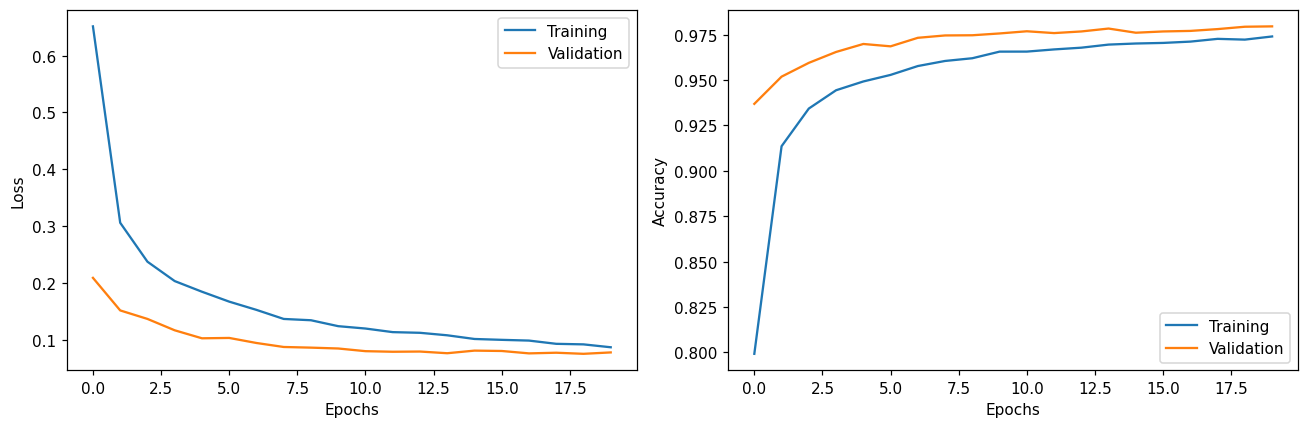

MNIST, raw


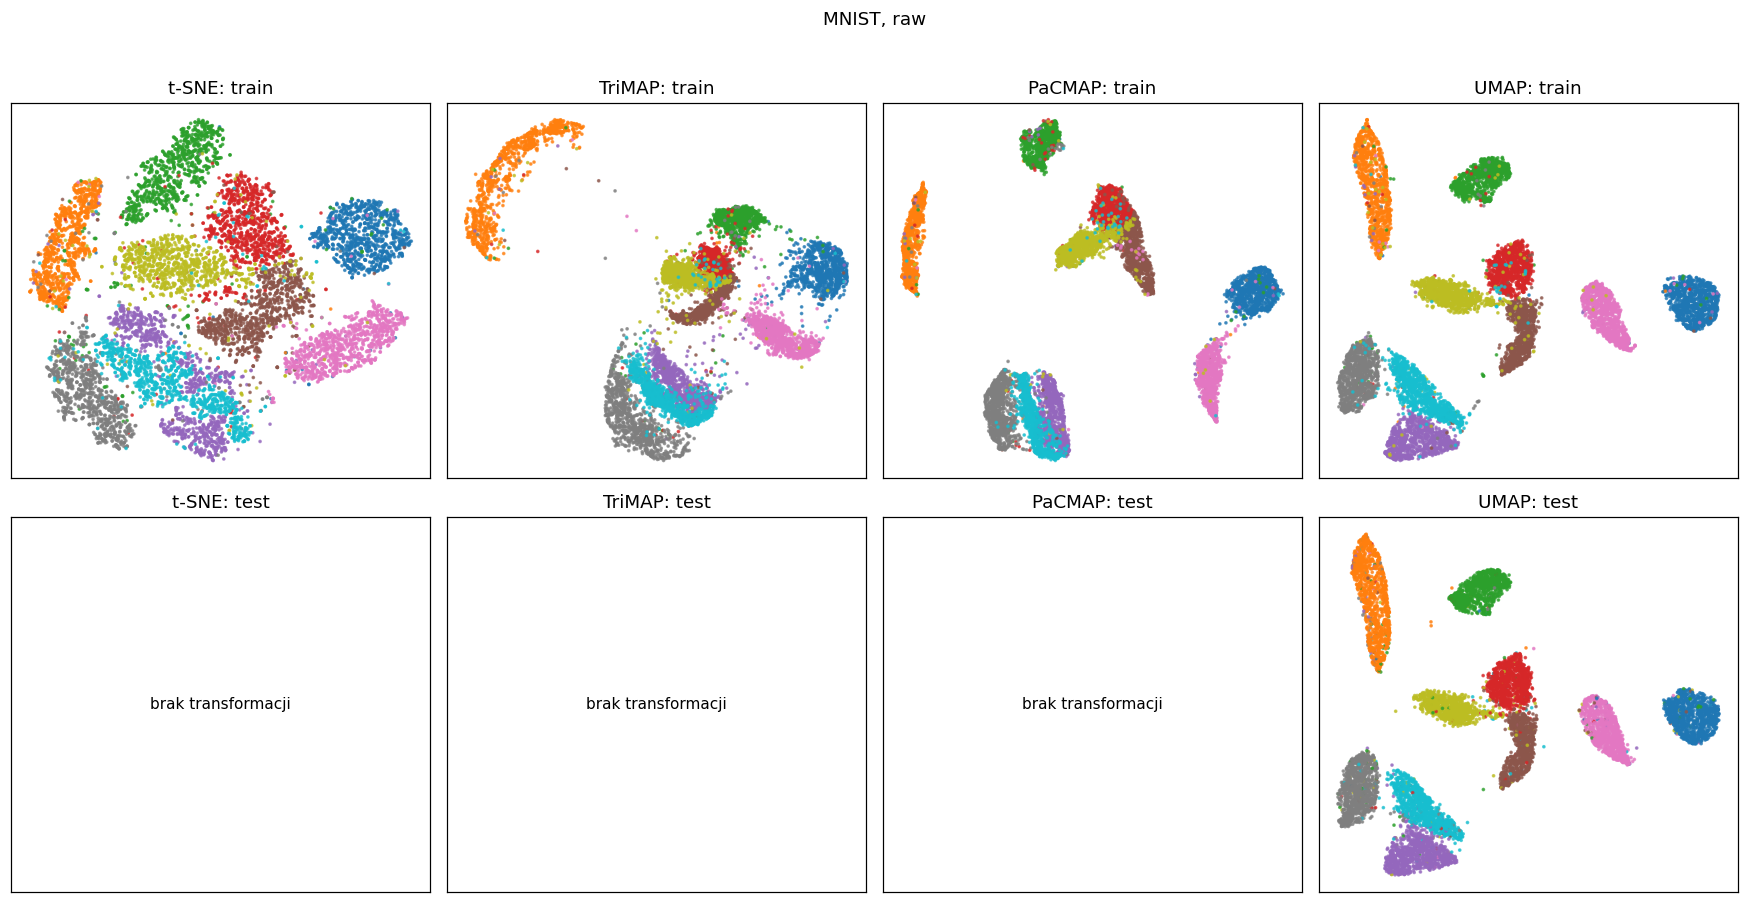

KNN (raw):
  n_neighbors=3, accuracy=0.9531
  n_neighbors=5, accuracy=0.9552


  n_neighbors=10, accuracy=0.9556
MNIST, layer1


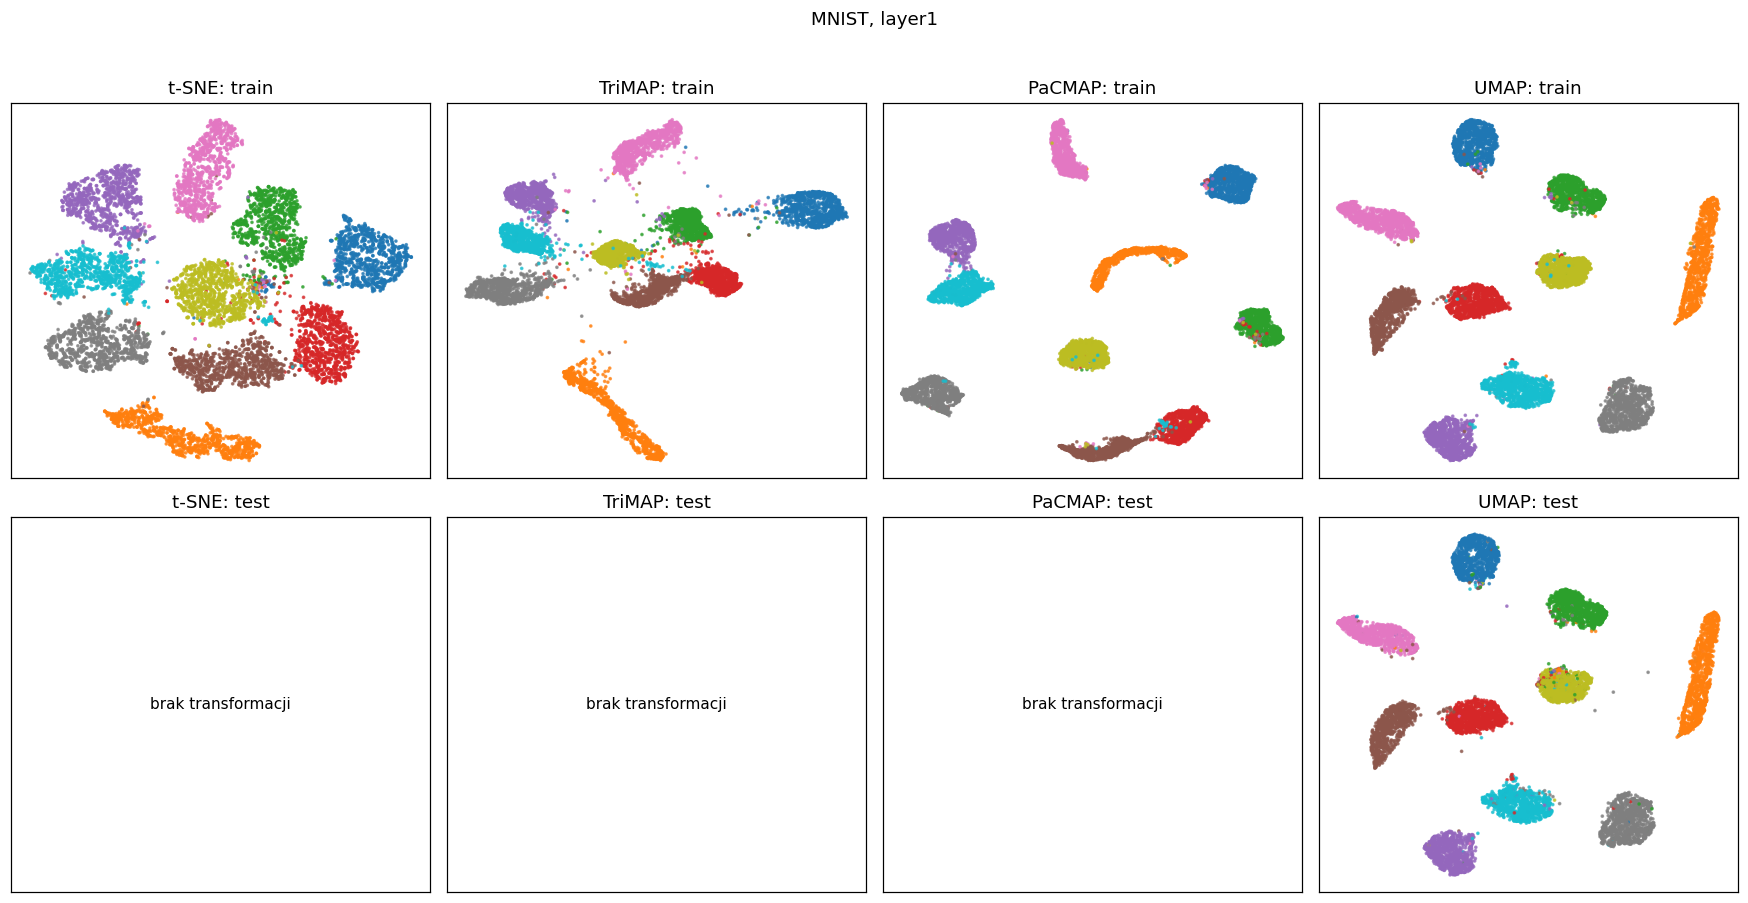

KNN (layer1):
  n_neighbors=3, accuracy=0.9696
  n_neighbors=5, accuracy=0.9701


  n_neighbors=10, accuracy=0.9706
MNIST, layer2


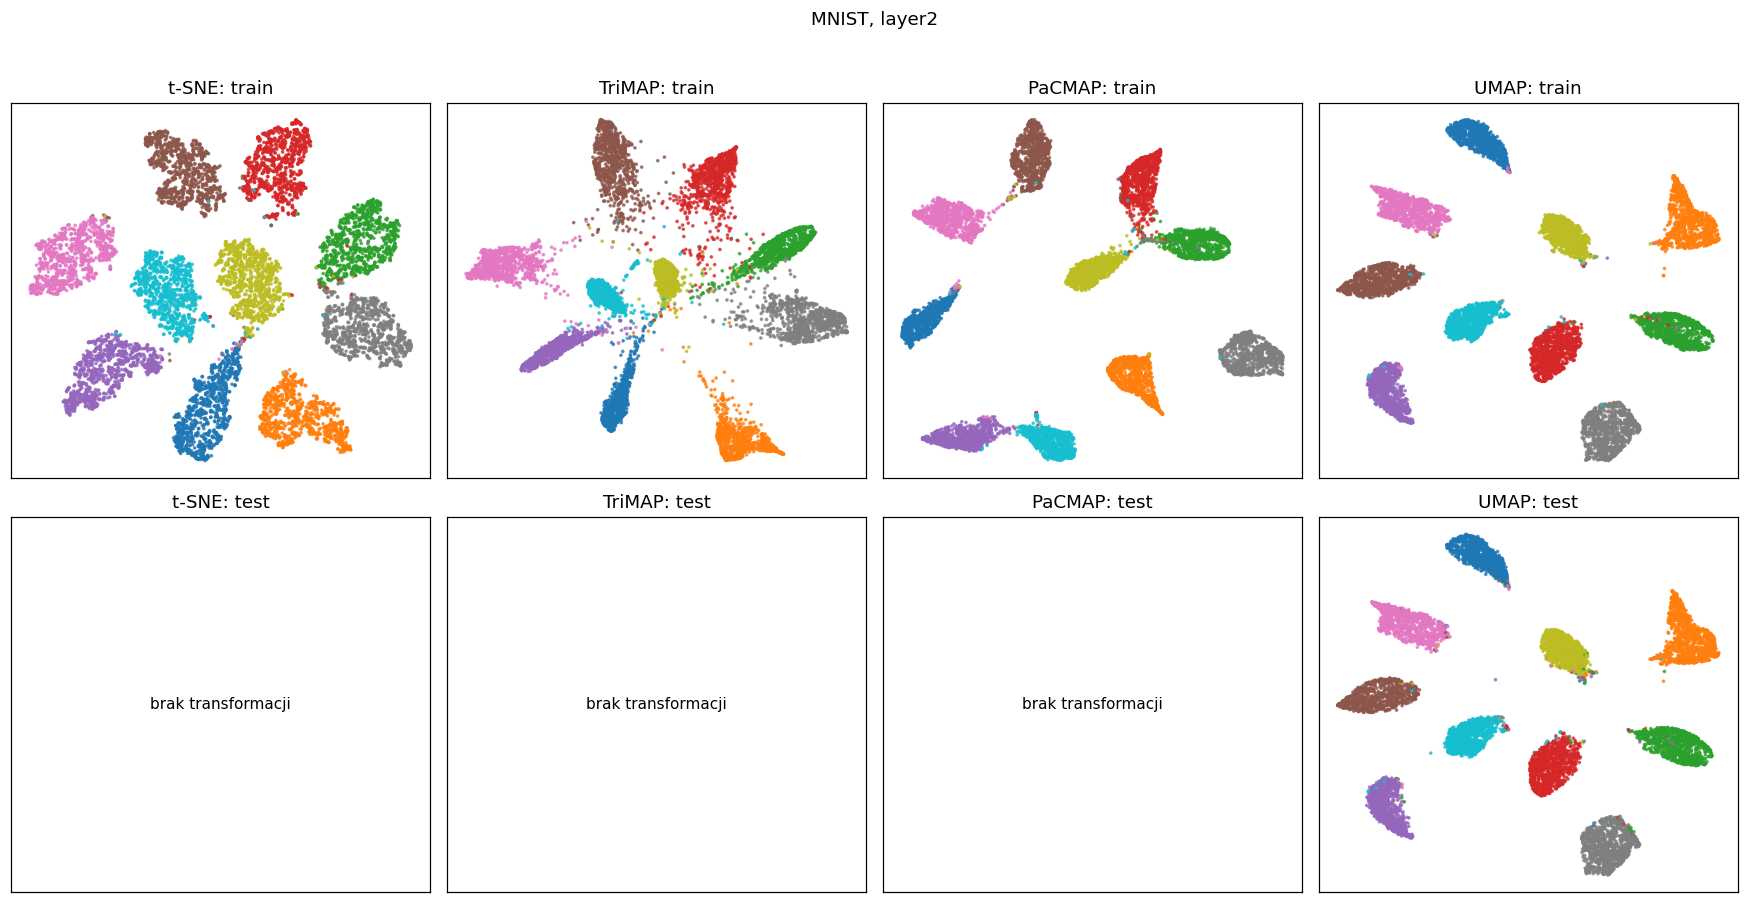

KNN (layer2):
  n_neighbors=3, accuracy=0.9756
  n_neighbors=5, accuracy=0.9770
  n_neighbors=10, accuracy=0.9769


,dataset,input,n_neighbors,accuracy
0,MNIST,raw,3,0.9531
1,MNIST,raw,5,0.9552
2,MNIST,raw,10,0.9556
3,MNIST,layer1,3,0.9696
4,MNIST,layer1,5,0.9701
5,MNIST,layer1,10,0.9706
6,MNIST,layer2,3,0.9756
7,MNIST,layer2,5,0.9770
8,MNIST,layer2,10,0.9769


In [14]:
mnist_results = run_dataset_experiment('MNIST', mnist.load_data)
mnist_results

## Cwiczenie 2: Fashion-MNIST

Powtarzamy procedure dla zbioru Fashion-MNIST (10 klas odziezy/obuwia).



--- Fashion-MNIST ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6995 - loss: 0.8540 - val_accuracy: 0.8222 - val_loss: 0.4842
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8030 - loss: 0.5661 - val_accuracy: 0.8420 - val_loss: 0.4231
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8224 - loss: 0.5054 - val_accuracy: 0.8502 - val_loss: 0.4069
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8348 - loss: 0.4700 - val_accuracy: 0.8559 - val_loss: 0.3867
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8412 - loss: 0.4507 - val_accuracy: 0.8601 - val_loss: 0.3763
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8443 - loss: 0.4386 - val_accuracy: 0.8651 - val_loss: 0.3675
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8491 - loss: 0.4234 - val_accuracy: 0.8661 - val_loss: 0.3578
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8510 - loss: 0.4163 - val_accuracy: 0.

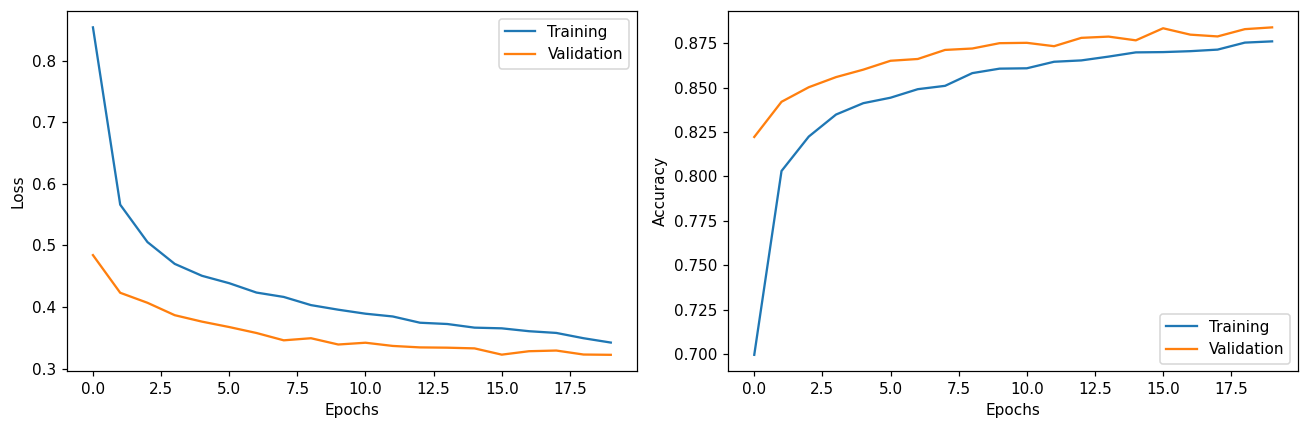

Fashion-MNIST, raw


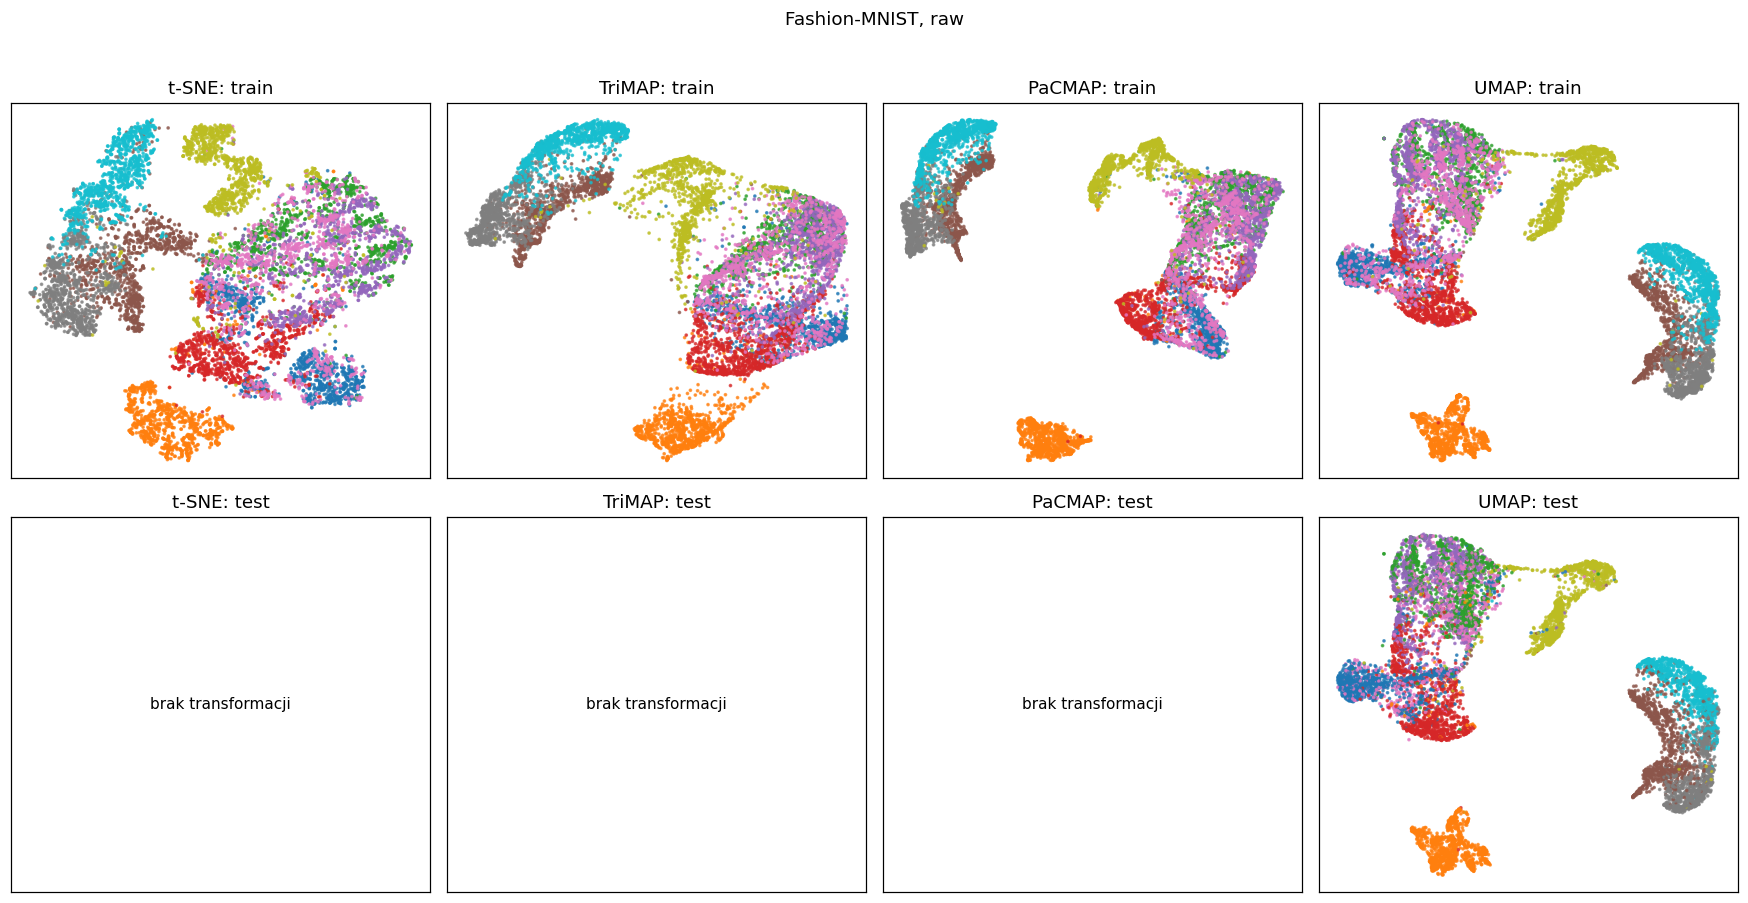

KNN (raw):
  n_neighbors=3, accuracy=0.7446
  n_neighbors=5, accuracy=0.7556


  n_neighbors=10, accuracy=0.7650
Fashion-MNIST, layer1


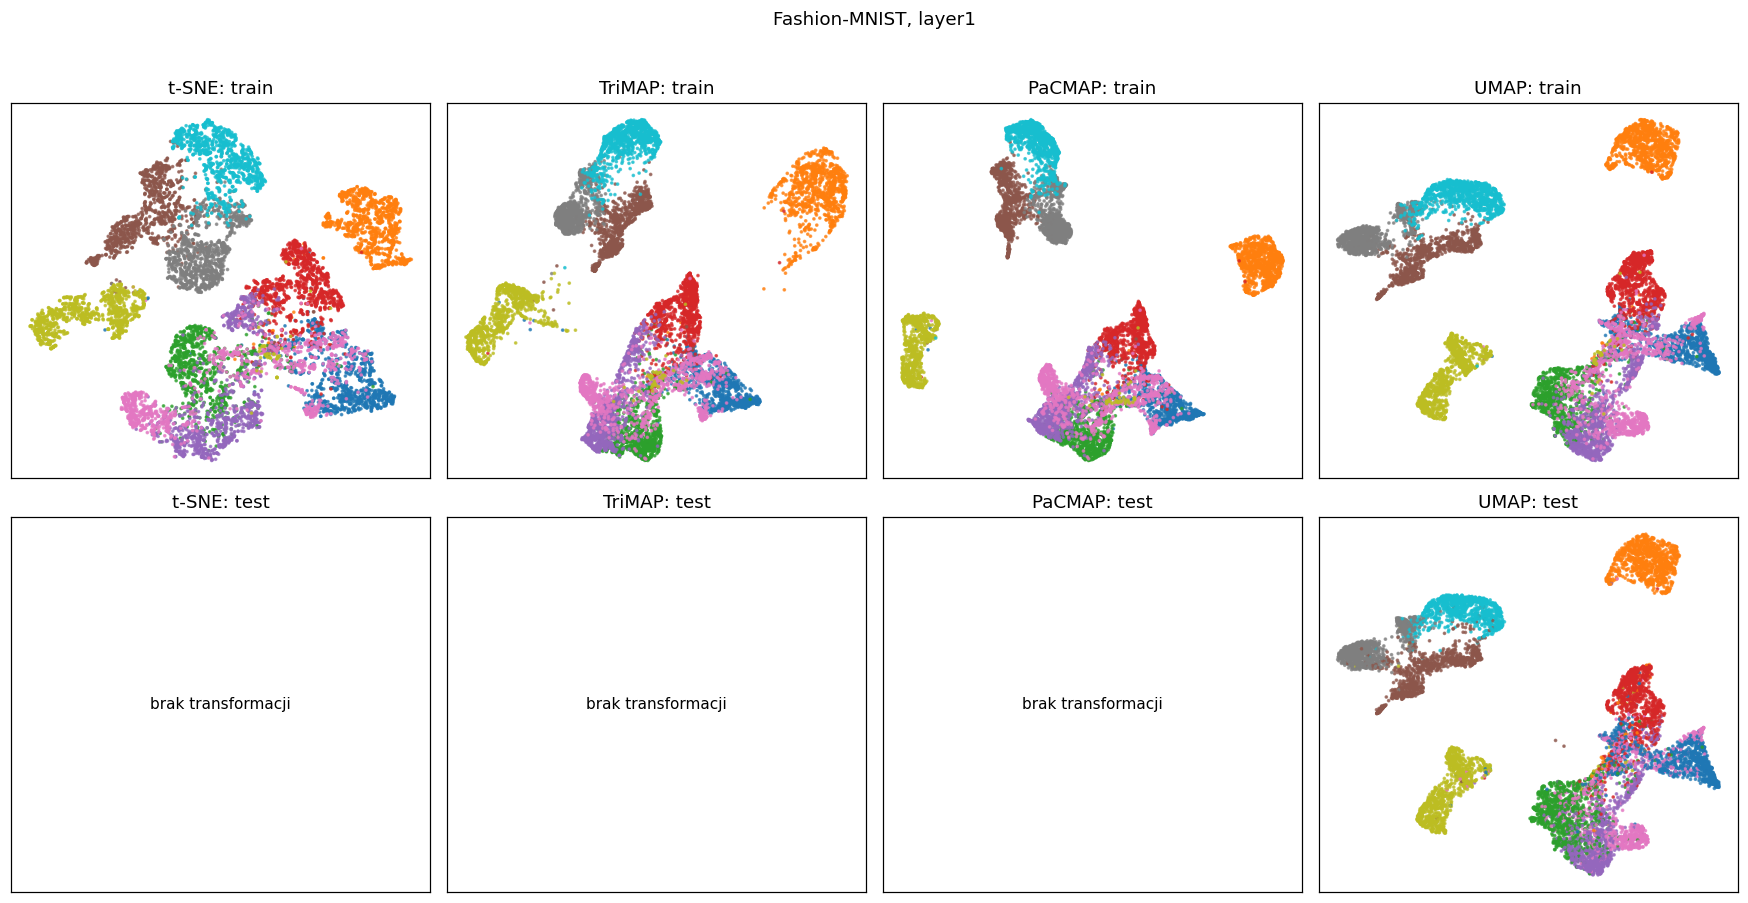

KNN (layer1):
  n_neighbors=3, accuracy=0.8374
  n_neighbors=5, accuracy=0.8457


  n_neighbors=10, accuracy=0.8518
Fashion-MNIST, layer2


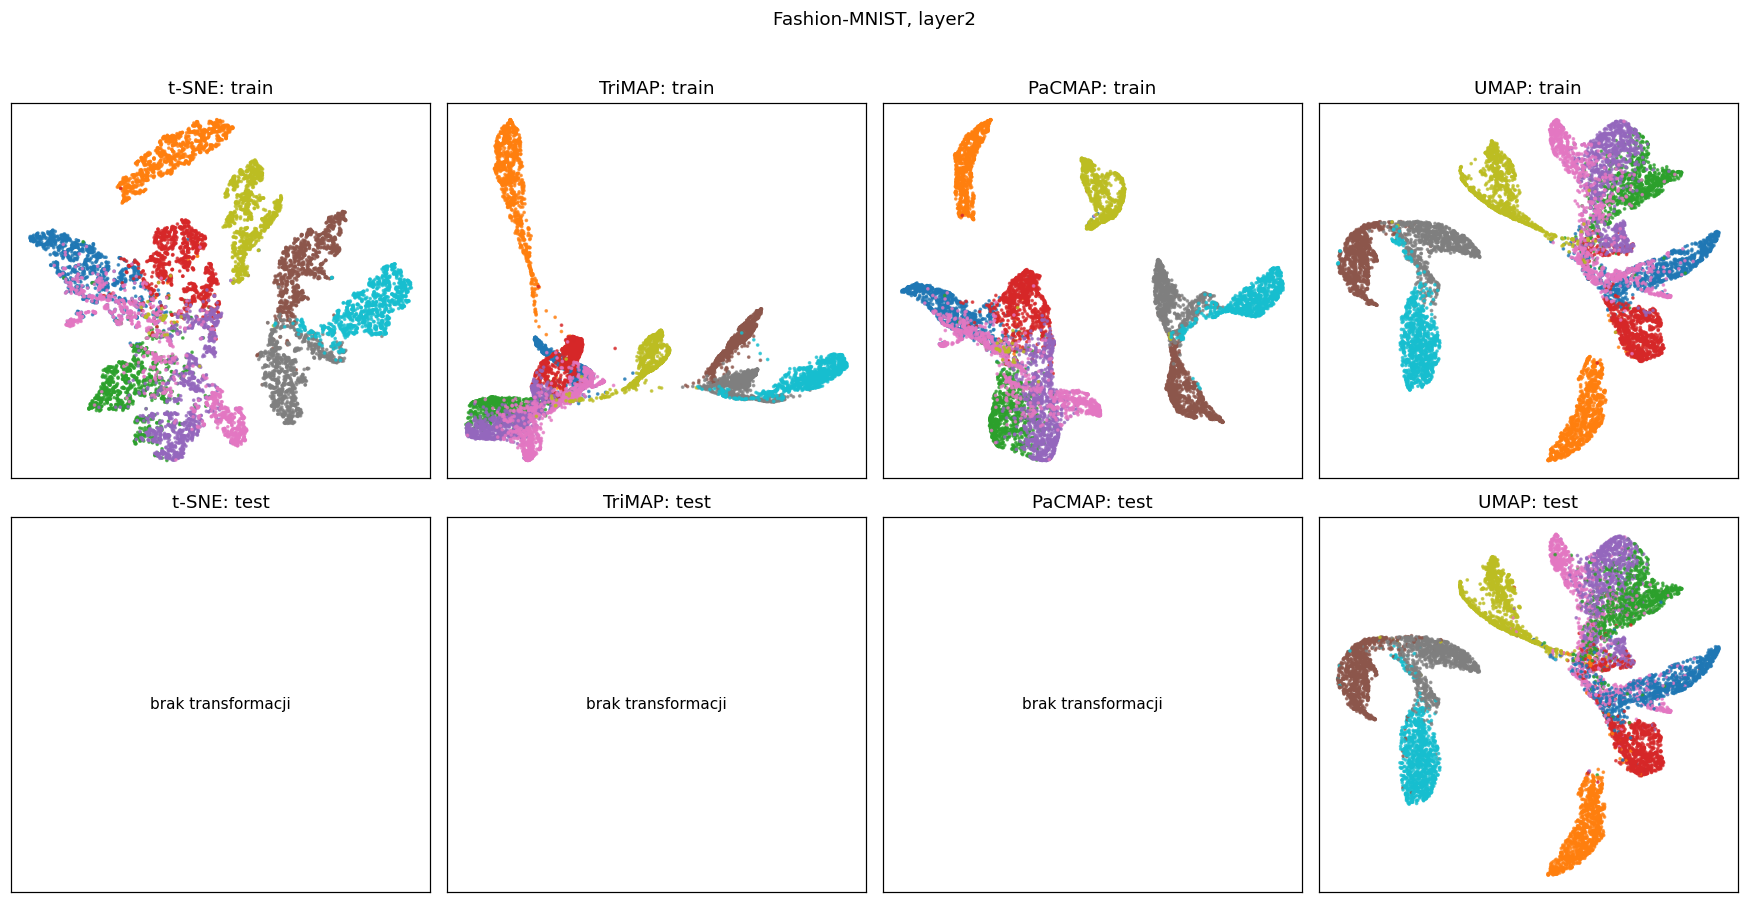

KNN (layer2):
  n_neighbors=3, accuracy=0.8481
  n_neighbors=5, accuracy=0.8545
  n_neighbors=10, accuracy=0.8625


,dataset,input,n_neighbors,accuracy
0,Fashion-MNIST,raw,3,0.7446
1,Fashion-MNIST,raw,5,0.7556
2,Fashion-MNIST,raw,10,0.7650
3,Fashion-MNIST,layer1,3,0.8374
4,Fashion-MNIST,layer1,5,0.8457
5,Fashion-MNIST,layer1,10,0.8518
6,Fashion-MNIST,layer2,3,0.8481
7,Fashion-MNIST,layer2,5,0.8545
8,Fashion-MNIST,layer2,10,0.8625


In [15]:
fashion_results = run_dataset_experiment('Fashion-MNIST', fashion_mnist.load_data)
fashion_results


In [16]:
comparison = pd.concat([mnist_results, fashion_results], ignore_index=True)
comparison_pivot = comparison.pivot_table(
    index=['dataset', 'input', 'n_neighbors'],
    values='accuracy',
    aggfunc='first',
)
comparison_pivot


accuracy
dataset       input  n_neighbors          
Fashion-MNIST layer1 3              0.8374
                     5              0.8457
                     10             0.8518
              layer2 3              0.8481
                     5              0.8545
                     10             0.8625
              raw    3              0.7446
                     5              0.7556
                     10             0.7650
MNIST         layer1 3              0.9696
                     5              0.9701
                     10             0.9706
              layer2 3              0.9756
                     5              0.9770
                     10             0.9769
              raw    3              0.9531
                     5              0.9552
                     10             0.9556

## Podsumowanie

### MNIST vs Fashion-MNIST

Na MNIST klastry cyfr sa wyrazniejsze niz klasy odziezy na Fashion-MNIST. Cyfry roznia sie glownie ksztaltem, a ubrania maja podobne tekstury (koszula, sweter, plaszcz sie nakladaja na wykresach).

Aktywacje warstw ukrytych daja lepsze grupowanie niz surowe piksele — szczegolnie widac to na Fashion-MNIST. Druga warstwa zwykle wyglada lepiej niz pierwsza.

Sieci osiagnely ok. 98% val accuracy na MNIST i 88% na Fashion-MNIST po 20 epokach.

### Wyniki KNN (UMAP)

| zbior | wejscie | k=3 | k=5 | k=10 |
|-------|---------|-----|-----|------|
| MNIST | raw | 95.3% | 95.5% | 95.6% |
| MNIST | layer1 | 96.5% | 96.7% | 96.8% |
| MNIST | layer2 | 97.4% | 97.5% | 97.5% |
| Fashion | raw | 74.5% | 75.6% | 76.5% |
| Fashion | layer1 | 83.6% | 84.5% | 85.2% |
| Fashion | layer2 | 84.6% | 85.5% | 86.2% |

Wszedzie layer2 > layer1 > raw. MNIST ma wyzsza accuracy niz Fashion (roznica ok. 11 p.p.). Na Fashion wiekszy skok po warstwach ukrytych (+10 p.p. raw do layer2) niz na MNIST (+2 p.p.).

Wieksze k (3 -> 10) lekko podbija accuracy; najwiekszy efekt na surowych danych Fashion.

### Metody redukcji

- **t-SNE** — ladne klastry na train, ale nie da sie rzutowac testu
- **TriMAP** — szybszy, OK na train
- **PaCMAP** — podobnie do UMAP na train; transform testu tu nie dzialal
- **UMAP** — jedyny uzyty do KNN, bo ma `fit_transform` i `transform`

### Mylone klasy (Fashion-MNIST)

Najczesciej razem: Shirt, Pullover, Coat, T-shirt/top. Sneaker i Ankle boot tez bywaja blisko. Trouser, Bag i Sandal sa latwiejsze do odroznienia.

### Pytania z cwiczenia 2

1. Siec na cyfrach uczy sie konturow; na ubraniach — faktury i ksztaltu, stad bardziej rozproszone embeddingi.
2. Fashion ma wieksza zmiennosc w klasach, wiec gorsza separacja i nizsza accuracy KNN.
3. Do klasyfikacji testu najlepszy UMAP. Do ogladania train tez dobry PaCMAP/t-SNE.
4. Na Fashion pomoglby CNN zamiast MLP — wykorzystalby strukture 2D obrazu.
